In [1]:
import torch
import torch.nn.functional as f
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
words = open('C:/Users/Acer/OneDrive/Desktop/YZ50/Week_3/names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [4]:
import random
random.seed(42)
random.shuffle(words)
words[:8]

['yuheng',
 'diondre',
 'xavien',
 'jori',
 'juanluis',
 'erandi',
 'phia',
 'samatha']

In [5]:
block_size = 3

def build_dataset(words):
    
    X, Y = [], []
    
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    
    return X,Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [6]:
for x,y in zip(Xtr[:20],Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '-->',itos[y.item()])

... --> y
..y --> u
.yu --> h
yuh --> e
uhe --> n
hen --> g
eng --> .
... --> d
..d --> i
.di --> o
dio --> n
ion --> d
ond --> r
ndr --> e
dre --> .
... --> x
..x --> a
.xa --> v
xav --> i
avi --> e


In [20]:
class Linear:
    
    def __init__(self, fan_in, fan_out, bias = True):
        self.weight = torch.randn((fan_in,fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    
    def __init__(self, dim, eps = 1e-5, momentum = 0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        #parameters trained with backprop
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # Calculate the forwardPass
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True, unbiased=False)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar 
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh():
    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

class Embeding():
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings,embedding_dim))
    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    def parameters(self):
        return [self.weight]

class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0],-1)
        return self.out
    def parameters(self):
        return []

class Sequential:
    def __init__(self,layers):
        self.layers = layers
    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [21]:
torch.manual_seed(42)

In [22]:
n_embd = 10
n_hidden = 200

#C = torch.randn((vocab_size, n_emb))
model = Sequential([
    Embeding(vocab_size,n_embd),
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias = False),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, vocab_size)
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

12097


In [19]:
Xtr.shape[0]

182625

In [23]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    
    ix = torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # Forward Pass
    logits = model(Xb)
    loss = f.cross_entropy(logits,Yb)
    
    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    


      0/ 200000: 3.2966
  10000/ 200000: 2.2338
  20000/ 200000: 2.4087
  30000/ 200000: 2.0973
  40000/ 200000: 2.3108
  50000/ 200000: 2.2121
  60000/ 200000: 1.9717
  70000/ 200000: 1.9769
  80000/ 200000: 2.6695
  90000/ 200000: 2.0842
 100000/ 200000: 2.2677
 110000/ 200000: 1.7606
 120000/ 200000: 2.2864
 130000/ 200000: 2.3457
 140000/ 200000: 2.1706
 150000/ 200000: 1.8354
 160000/ 200000: 1.7673
 170000/ 200000: 2.2326
 180000/ 200000: 2.0701
 190000/ 200000: 2.1323


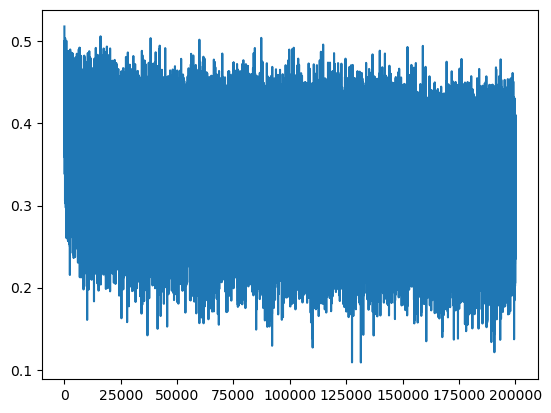

In [24]:
plt.plot(lossi)

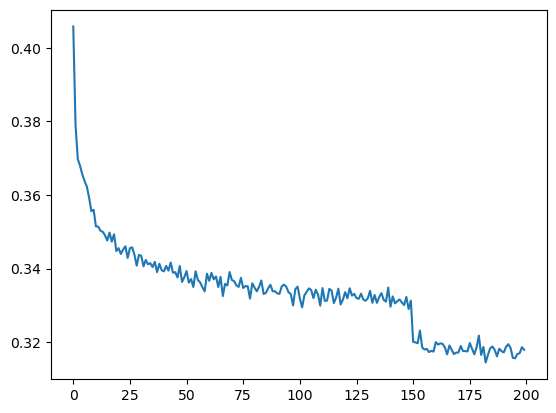

In [25]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [30]:
for layer in model.layers:
    layer.training = False

In [36]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr,Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]

    logits = model(x)
    loss = f.cross_entropy(logits,y)
    print(split, loss.item())
    
split_loss('train')
split_loss('val')


train 3.1952474117279053
val 3.300936698913574


In [28]:
bn = model.layers[3]

print("running_mean:", torch.isfinite(bn.running_mean).all().item())
print("running_var:", torch.isfinite(bn.running_var).all().item())
print("min variance:", bn.running_var.min().item())

running_mean: True
running_var: True
min variance: 0.21333739161491394


In [39]:
for _ in range(20):
    
    out = []
    context = [0] * block_size
    
    while True:
        logits = model(torch.tensor([context]))
        probs = f.softmax(logits,dim=1)
        ix = torch.multinomial(probs, num_samples = 1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))


grachim.
wyedhanvious.
corbarkelziershitt.
guh.
perchaycentrer.
grey.
graclynn.
dhani.
grayshawleveesiia.
chailee.
gregce.
grachett.
georgiani.
grachilvicter.
gregi.
grachaycley.
georginestick.
guan.
hone.
cchelmeryn.
